# PV + battery energy storage

A standalone PNM-data demonstration: load data, declare the PV/BES assets and economics, dispatch, calculate LCOE, plot, and run resilience cases.

In [1]:
from pathlib import Path
import sys
import pandas as pd

root = Path.cwd()
while not (root / 'enliten').is_dir():
    if root.parent == root: raise RuntimeError('Run from inside the ENLITEN repository.')
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
from enliten import ChargingPath, Generation, LCOECalculator, Site, Storage, System
data_dir = root / 'examples' / 'data'

def profile(filename):
    frame = pd.read_csv(data_dir / filename)
    return pd.Series(frame['PNM'].to_numpy(float), index=pd.to_datetime(frame.iloc[:, 0], utc=True))

demand_full = profile('PNM_demand.csv')
pv_full = profile('PNM_pv_ac_1MW_av.csv')
assert demand_full.index.equals(pv_full.index)

hours, start = 24 * 14, pd.Timestamp('2023-07-01', tz='UTC')
window = demand_full.index.get_loc(start)
load = (demand_full.iloc[window:window + hours] * 0.05).rename('load_MW')
pv_multiplier, bes_capacity_MWh, bes_power_MW = 3_000.0, 750.0, 150.0
pv_capex = pv_full.max() * pv_multiplier * 1_000 * 1_430
pv_opex = pv_full.max() * pv_multiplier * 1_000 * 24
bes_capex = bes_capacity_MWh * 1_000 * 300

site = Site('microgrid')
pv = Generation('pv', site, pv_full.iloc[window:window + hours] * pv_multiplier, 'electric', capex=pv_capex, opex=pv_opex)
bes = Storage('bes', site, bes_capacity_MWh, bes_power_MW, 'electric', 'electric', 0.90,
              maximum_stored_energy_rate_MW=bes_power_MW, capex=bes_capex, opex=0.025 * bes_capex)
path = ChargingPath('pv', 'bes', 'electric', 'electric', 0.90, bes_power_MW / 0.90)
system = System(load, [bes, pv], [path])
system.timeseries.head(24)

,load_MW,grid_to_load_MWh_electric,unmet_load_MWh_electric,export_energy_MWh_electric,pv_available_MW_electric,pv_to_load_MWh_electric,pv_to_grid_MWh_electric,pv_curtailed_MWh_electric,pv_to_bes_MWh_electric,pv_to_bes_stored_MWh_electric,bes_MWh_electric,bes_to_load_MWh_electric,bes_loss_MWh_electric,microgrid_POI_MW_electric
date_time,,,,,,,,,,,,,,
2023-07-01 00:00:00+00:00,107.31,0.000000,0.0,0.0,64.067812,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-07-01 01:00:00+00:00,107.35,79.270463,0.0,0.0,28.079537,28.079537,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,28.079537
2023-07-01 02:00:00+00:00,103.87,103.252087,0.0,0.0,0.617913,0.617913,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.617913
2023-07-01 03:00:00+00:00,101.82,101.820000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-07-01 04:00:00+00:00,98.23,98.230000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-07-01 05:00:00+00:00,90.94,90.940000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-07-01 06:00:00+00:00,83.81,83.810000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-07-01 07:00:00+00:00,78.68,78.680000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-07-01 08:00:00+00:00,75.27,75.270000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


In [2]:
system.operation_metrics()

{'operating_hours': 335,
 'load_MWh_electric': 31742.63000000001,
 'generation_to_load_MWh_electric': 15669.107367702063,
 'storage_to_load_MWh_electric': 4074.7676421699884,
 'system_to_load_MWh_electric': 19743.875009872052,
 'grid_to_load_MWh_electric': 11998.754990127949,
 'unmet_load_MWh_electric': 0.0,
 'export_energy_MWh_electric': 0.0,
 'percent_load_met': 99.99999999999997,
 'percent_load_by_system': 62.19987130830699,
 'system_capex_USD': 440580965.5543319,
 'system_annual_OM_USD': 9243142.079233542,
 'pv_curtailed_MWh_electric': 0.0,
 'load_annual_MWh_electric': [31742.63],
 'system_to_load_annual_MWh_electric': [19743.875009872052],
 'grid_to_load_annual_MWh_electric': [11998.754990127949],
 'export_energy_annual_MWh_electric': [0.0],
 'annual_electricity_sales_USD': [0.0],
 'annual_electricity_purchases_USD': [0.0],
 'system_annual_VOM_USD': 0.0,
 'system_augment_USD': [0.0],
 'system_augment': [0.0]}

In [3]:
lcoe_metrics = LCOECalculator.from_system(system, analysis_period=30).calculate_lcoe_metrics()
lcoe_metrics

{'PVD': 0.7673732703594979,
 'FCR_AT': 0.036148074230068654,
 'FCR_BT': 0.05294061134598742,
 'CRF': 0.07650022967642069,
 'NPV_cash_flow': -459809205.93344665,
 'IRR': nan,
 'payback_period': None,
 'LCOE_real_USD_kWh_BT': 1.8327030031411768,
 'LCOE_real_USD_kWh_AT': 1.2905854712531595}

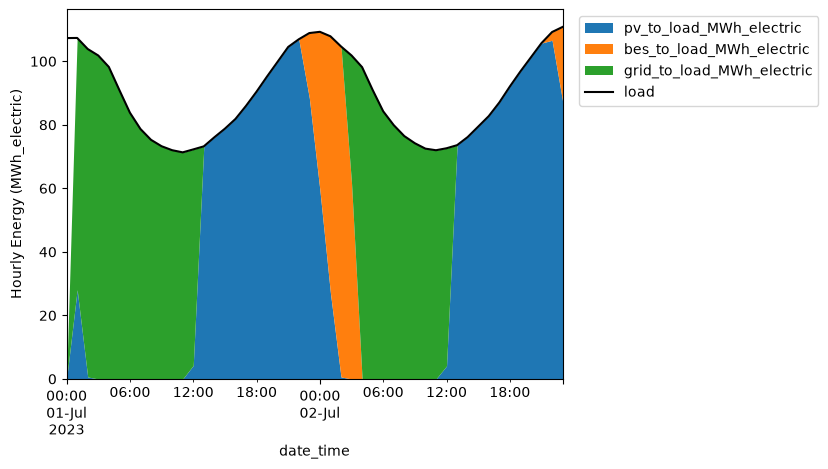

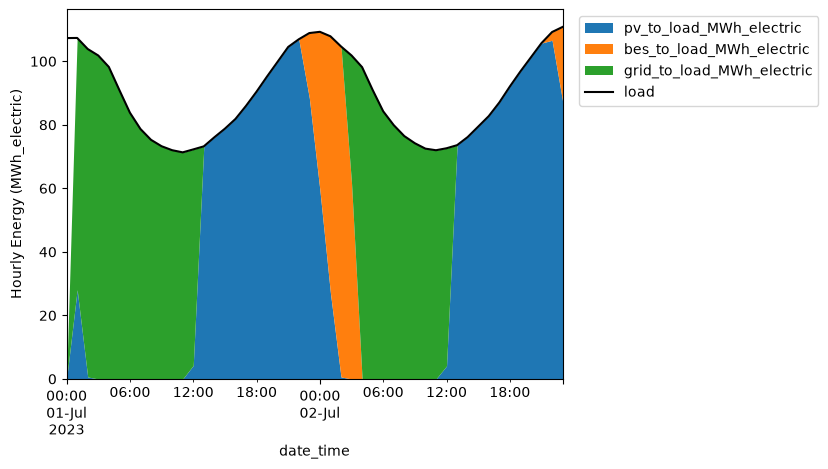

In [4]:
fig, ax = system.timeseries_plot_source(start_date=0, days=2)
fig

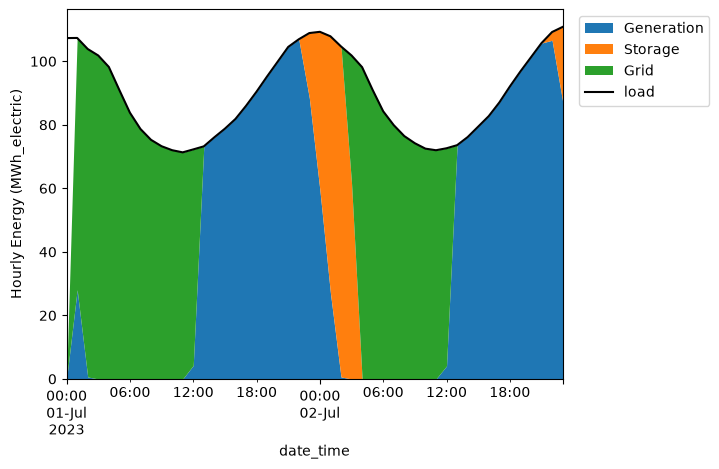

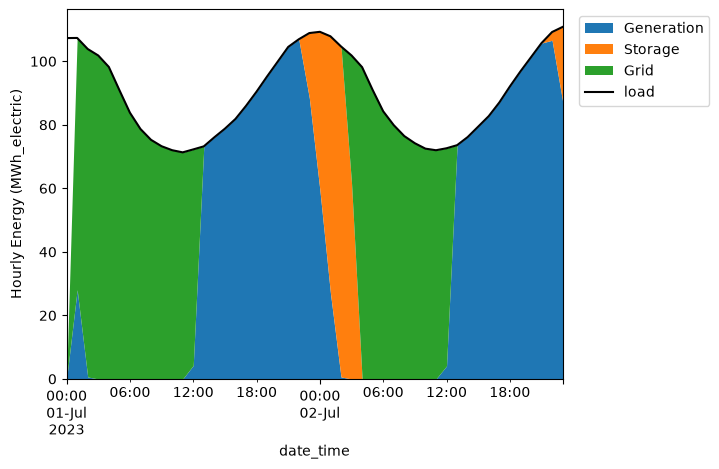

In [5]:
fig, ax = system.timeseries_plot_group(start_date=0, days=2)
fig

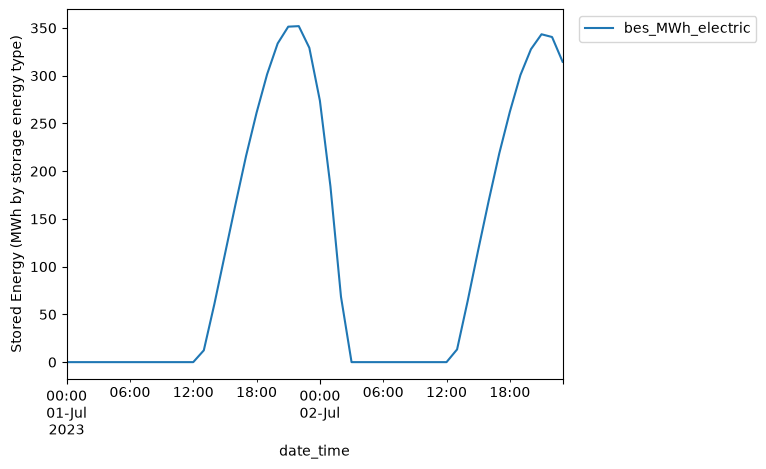

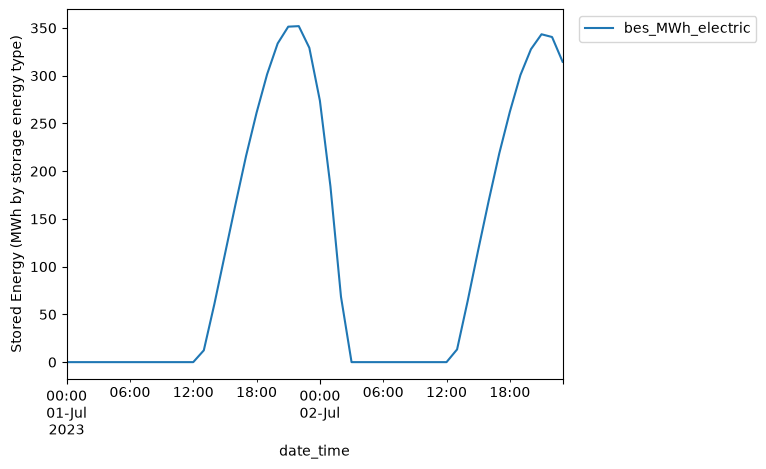

In [6]:
fig, ax = system.plot_storage_capacity(start_date=0, days=2)
fig

In [7]:
cases = system.resilience_cases(critical_load_MW=20.0, target_hours=24, n_starts=20, seed=7)
display(cases)
system.resilience_summary

,start_hour,actual_duration_hours,full_duration_hours,actual_reaches_target,full_reaches_target,to_end_actual,to_end_full,pct_target_energy_actual,pct_target_energy_full,target_energy_actual_MWh_electric,target_energy_full_MWh_electric,target_energy_actual,target_energy_full
0,165,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
1,77,0,24,False,True,False,True,0.719628,1.0,134.578661,0.0,134.578661,0.0
2,202,0,24,False,True,False,True,0.924325,1.0,36.323983,0.0,36.323983,0.0
3,333,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
4,24,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
5,37,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
6,274,0,24,False,True,False,True,0.922096,1.0,37.393759,0.0,37.393759,0.0
7,48,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
8,187,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
9,298,0,24,False,True,False,True,0.920424,1.0,38.196392,0.0,38.196392,0.0


{'n_starts': 20,
 'pct_meets_actual': 60.0,
 'pct_meets_full': 100.0,
 'actual_reaches_end_pct': 60.0,
 'full_reaches_end_pct': 100.0,
 'tenth_pctile_actual_hrs': 0.0,
 'tenth_pctile_target_energy_actual_MWh_electric': 0.0,
 'tenth_pctile_target_energy_actual': 0.0,
 'tenth_pctile_pct_target_energy_actual': 71.93519016566484,
 'fiftieth_pctile_actual_hrs': 24.0,
 'fiftieth_pctile_target_energy_actual_MWh_electric': 0.0,
 'fiftieth_pctile_target_energy_actual': 0.0,
 'fiftieth_pctile_pct_target_energy_actual': 100.0,
 'ninetieth_pctile_actual_hrs': 24.0,
 'ninetieth_pctile_target_energy_actual_MWh_electric': 134.7110872048088,
 'ninetieth_pctile_target_energy_actual': 134.7110872048088,
 'ninetieth_pctile_pct_target_energy_actual': 100.0,
 'pct_meets_target_energy_actual': 60.0,
 'tenth_pctile_full_hrs': 24.0,
 'tenth_pctile_target_energy_full_MWh_electric': 0.0,
 'tenth_pctile_target_energy_full': 0.0,
 'tenth_pctile_pct_target_energy_full': 100.0,
 'fiftieth_pctile_full_hrs': 24.0,
 '